# Memory Experiment — H-code family

**[DEMO]** — bare X/Z memory for `HCode(n)`, the even-n `[[n,n−4,2]]` family.
`N=6` reproduces the H6 patch. Adapted from Maggie Bao's [PR #98](https://github.com/QuTone/LightStim/pull/98).

In [1]:
import sys
from pathlib import Path

ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "lightstim").is_dir() and (path / "pyproject.toml").exists()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lightstim.noise.config import NoiseConfig
from lightstim.protocols import MemoryExperiment
from lightstim.qec_code.H_code import HCode, HCodeExtractionBlock
from IPython.display import SVG, display

## Configuration

In [2]:
N = 6
ROUNDS = 3
SHOTS = 64
SE_BLOCK = HCodeExtractionBlock

patch = HCode(n=N)
info = patch.get_info()
print({key: info[key] for key in ("n_data", "k", "code_distance")})

{'n_data': 6, 'k': 2, 'code_distance': 2}


## Build the memory circuit

The extraction block is explicit. Omitting it selects the same H-code default.
`basis` sets data preparation/readout; each SE round measures both X and Z checks.

In [3]:
def build_memory(basis):
    circuit = MemoryExperiment(
        qec_patch=HCode(n=N), extraction_block_class=SE_BLOCK,
        rounds=ROUNDS, basis=basis, if_detector=True,
    ).build()
    sample = circuit.compile_detector_sampler(seed=98).sample(
        SHOTS, append_observables=True
    )
    assert not sample.any()
    circuit.detector_error_model()
    print(f"basis {basis}: qubits={circuit.num_qubits}  "
          f"detectors={circuit.num_detectors}  observables={circuit.num_observables}  "
          "noiseless all-zero=True")
    return circuit

circuits = {basis: build_memory(basis) for basis in ("Z", "X")}

basis Z: qubits=10  detectors=12  observables=2  noiseless all-zero=True
basis X: qubits=10  detectors=12  observables=2  noiseless all-zero=True


## Detector-slice view

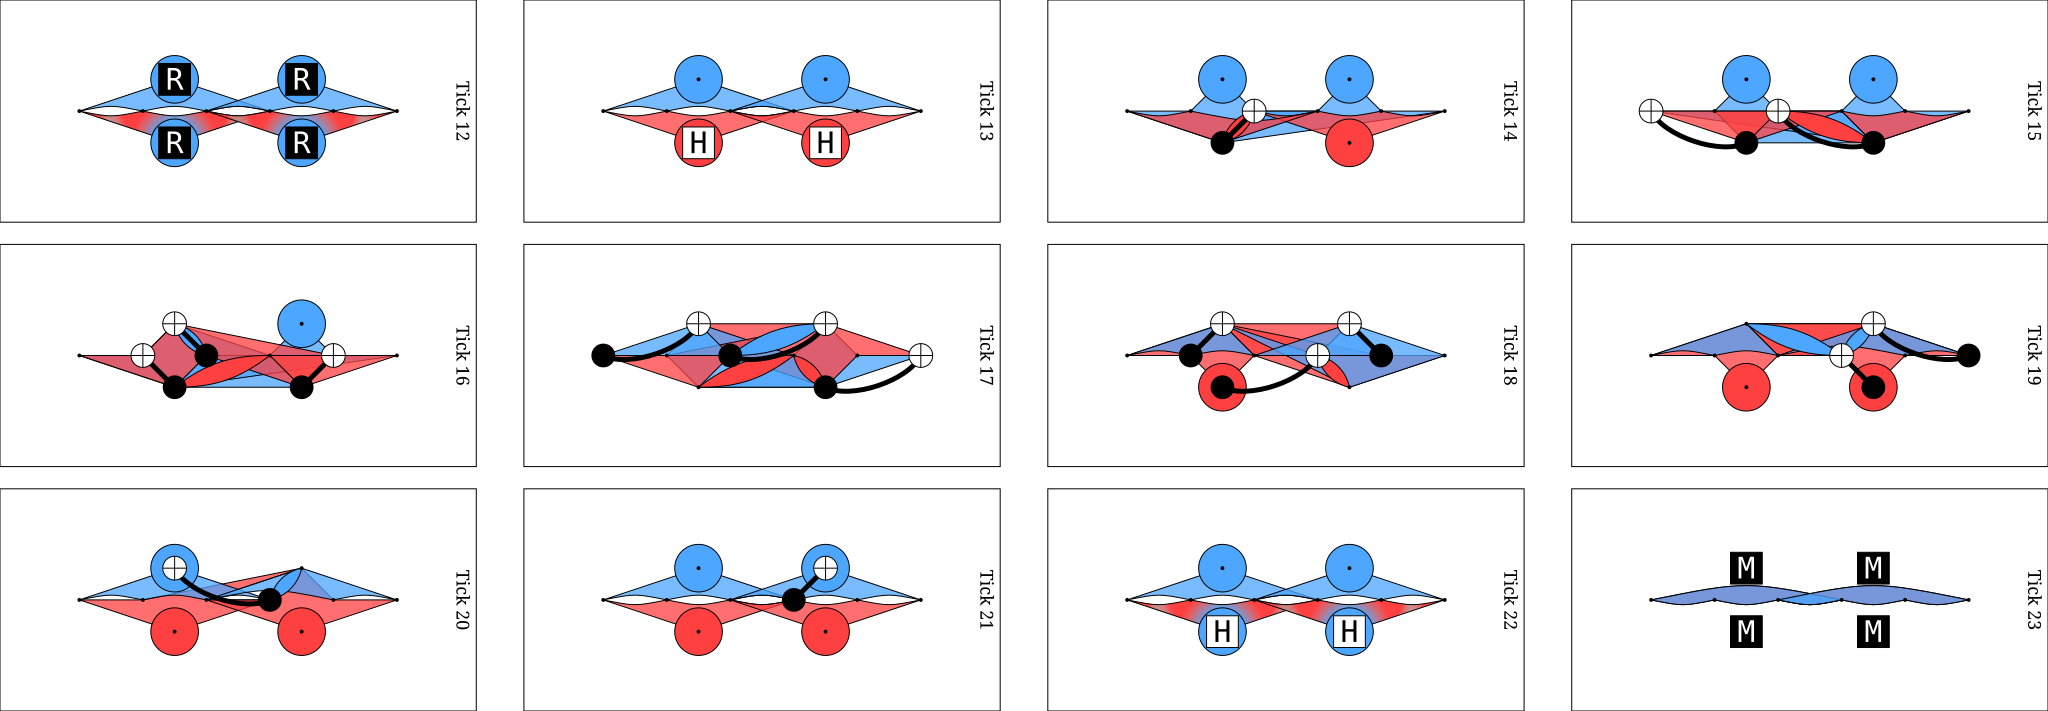

In [4]:
display(SVG(str(circuits["Z"].diagram(
    "detslice-with-ops-svg", tick=range(N+6, 2*(N+6))
))))

## Circuit fault check

Check that no undecomposed single-fault signature flips a logical without a
detector. The graphlike witness supplies an upper bound; the full audit and
postselection scaling tests live in `tests/test_H_code_fault_distance.py`.

In [5]:
p = 1e-3
for basis in ("Z", "X"):
    noisy = MemoryExperiment(
        qec_patch=HCode(n=N), extraction_block_class=SE_BLOCK,
        rounds=ROUNDS, basis=basis,
        noise_params=NoiseConfig(p_1q=p, p_2q=p, p_meas=p, p_reset=p, p_idle=0),
    ).build()
    errors = [e for e in noisy.detector_error_model(decompose_errors=False).flattened()
              if e.type == "error"]
    logical_only = [e for e in errors
                    if any(t.is_logical_observable_id() for t in e.targets_copy())
                    and not any(t.is_relative_detector_id() for t in e.targets_copy())]
    assert not logical_only
    witness = noisy.shortest_graphlike_error(canonicalize_circuit_errors=True)
    print(f"basis {basis}: undetected single-fault signatures={len(logical_only)}, "
          f"graphlike witness length={len(witness)}")
    assert len(witness) == 2

basis Z: undetected single-fault signatures=0, graphlike witness length=2
basis X: undetected single-fault signatures=0, graphlike witness length=2
